<a href="https://colab.research.google.com/github/2403a52029-lab/ML_Assignments/blob/main/ML_LAB_09_2403A52029_B_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Kaggle (only first time if needed)
!pip install kaggle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
# Upload your CSV file in Colab first
df = pd.read_csv("/content/heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:
# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Drop 'id' column as it's not a feature
df_processed = df.drop("id", axis=1)

# Separate features (X) and target (y)
X = df_processed.drop("num", axis=1)
y = df_processed["num"]

# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

# Impute missing numerical values with the median
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# Impute missing categorical values with the mode
for col in categorical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mode()[0])

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (IMPORTANT for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


/tmp/ipython-input-699552557.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mode()[0])


In [7]:
k_values = [3, 5, 7, 11, 15]

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    accuracy_list.append(acc)
    precision_list.append(pre)
    recall_list.append(rec)
    f1_list.append(f1)

    print(f"\nResults for k = {k}")
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1-score :", f1)


Results for k = 3
Accuracy : 0.5815217391304348
Precision: 0.5188492063492063
Recall   : 0.5815217391304348
F1-score : 0.5437054402918869

Results for k = 5
Accuracy : 0.5869565217391305
Precision: 0.5425732480080306
Recall   : 0.5869565217391305
F1-score : 0.5623313343328337

Results for k = 7
Accuracy : 0.6304347826086957
Precision: 0.5785733607824399
Recall   : 0.6304347826086957
F1-score : 0.5993541546173126

Results for k = 11
Accuracy : 0.6195652173913043
Precision: 0.5692609287461533
Recall   : 0.6195652173913043
F1-score : 0.5902217386166917

Results for k = 15
Accuracy : 0.5869565217391305
Precision: 0.5336962147808084
Recall   : 0.5869565217391305
F1-score : 0.5577006992305978


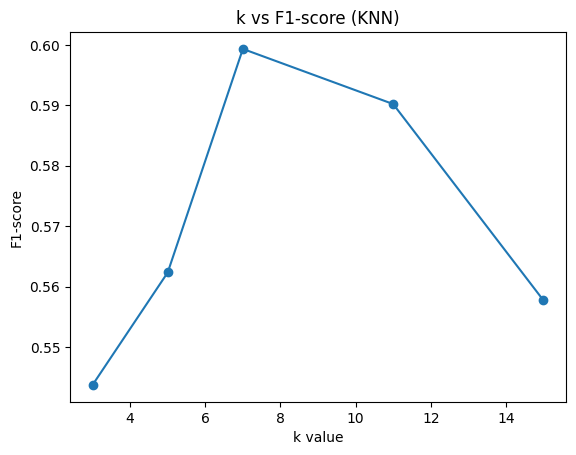

In [8]:
plt.figure()
plt.plot(k_values, f1_list, marker='o')
plt.xlabel("k value")
plt.ylabel("F1-score")
plt.title("k vs F1-score (KNN)")
plt.show()

In [9]:
results = pd.DataFrame({
    "k": k_values,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-score": f1_list
})

results

,k,Accuracy,Precision,Recall,F1-score
0,3,0.581522,0.518849,0.581522,0.543705
1,5,0.586957,0.542573,0.586957,0.562331
2,7,0.630435,0.578573,0.630435,0.599354
3,11,0.619565,0.569261,0.619565,0.590222
4,15,0.586957,0.533696,0.586957,0.557701
